In [1]:
# import ROOT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import uproot
import awkward as ak
import pandas as pd
from scipy.optimize import curve_fit

In [2]:
import time

file_path = "/raid1/genli/Data_D2O/M2_data/run4598_processed_H2O_v5.root"
output_path = "/raid1/genli/Data_D2O/output_from_jupyter/"

# grab the run number from the file path
run_num = str(file_path.split("/")[-1].split("_")[0][3:])

# Read only the branches we actually need (major speedup vs reading full tree)
scalar_branches = ["eventID", "nsTime", "triggerBits"]
array_branches = ["pulseH", "area"]
needed_branches = scalar_branches + array_branches

t0 = time.perf_counter()
with uproot.open(file_path) as file:
    tree = file["tree"]
    np_arrays = tree.arrays(needed_branches, library="np")

# Build DataFrame from scalars
# (copy=False avoids unnecessary memory copies when possible)
df = pd.DataFrame({key: np_arrays[key] for key in scalar_branches}, copy=False)

# Store fixed-size arrays (23 elements each) inside cells
for key in array_branches:
    df[key] = list(np_arrays[key])

print(df.head())

# Save DataFrame (arrays remain inside cells)
out_csv = f"{output_path}run{run_num}_data.csv"
df.to_csv(out_csv, index=False)

print(f"Saved: {out_csv}")
print(f"Rows: {len(df):,}")
print(f"Elapsed: {time.perf_counter() - t0:.2f} s")

   eventID   nsTime  triggerBits  \
0        0   878744            0   
1        6  6153816            2   
2        7  6679384           32   
3        9  8597992            2   
4       10  9544856           16   

                                              pulseH  \
0  [1549.9, 1593.65, 1389.9, 1813.45, 1140.65, 14...   
1  [2.5500000000000114, 2.0500000000000114, 4.449...   
2  [1.3000000000000114, 3.1500000000000057, 2.949...   
3  [2.3499999999999943, 2.8000000000000114, 4.0, ...   
4  [10.550000000000011, 24.05000000000001, 16.449...   

                                                area  
0  [9160.299999999997, 8849.049999999996, 8025.29...  
1  [4.350000000000193, -12.149999999999807, 28.64...  
2  [-5.899999999999807, -0.44999999999990337, 2.1...  
3  [-0.050000000000096634, 0.6000000000001933, 12...  
4  [44.35000000000019, 120.8500000000002, 46.6499...  


KeyboardInterrupt: 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# --- Landau backend ---
# If scipy.stats.landau exists in your SciPy, use it. Otherwise fallback to Moyal (common approximation).
try:
    from scipy.stats import landau as landau_dist
    HAVE_TRUE_LANDAU = True
except Exception:
    from scipy.stats import moyal as landau_dist
    HAVE_TRUE_LANDAU = False
    print("[INFO] scipy.stats.landau not found, using scipy.stats.moyal as Landau approximation.")


# ---------------------------
# Panel grouping (your definition)
# ---------------------------
PANEL_GROUP = {
    1: "top", 2: "top",
    3: "top", 4: "wide", 5: "top", 6: "top",
    7: "top", 8: "thin", 9: "thin", 10: "thin",
}

sipm_channels = list(range(12, 22))  # Corresponding to SiPM 1..10
# ---------------------------
# Landau(+C) model for fitting histogram counts
# ---------------------------
def landau_plus_const(x, A, mpv, sigma, C):
    # PDF normalized to 1 over (-inf, +inf). A scales it to histogram counts.
    return A * landau_dist.pdf(x, loc=mpv, scale=sigma) + C

def landau_plus_exp(x, A, mpv, sigma, tau, B, x0, C):
    # A * Landau + B * exp(-(x - x0)/tau) + C
    return A * landau_dist.pdf(x, loc=mpv, scale=sigma) + B * np.exp(-(x - x0)/tau) + C


def extract_channel_data(df_muon, column, j):
    """
    column: "pulseH" or "area"
    j: index inside your array (you used 12..21)
    """
    arr = np.stack(df_muon[column].values)  # shape (Nevents, Nch)
    return arr[:, j].astype(float)


def fit_one_channel_hist(data, bins, hist_range, fit_range, mpv_bounds=None):
    """
    Fit a Landau(+C) to histogram counts.
      - hist_range: (xmin, xmax) for histogram construction
      - fit_range: (xfit_min, xfit_max) for selecting bins to fit
      - mpv_bounds: (mpv_min, mpv_max) for MPV parameter constraint (panel-dependent)
                    If None -> defaults to fit_range.
    """
    # Build histogram in fixed range
    counts, edges = np.histogram(data, bins=bins, range=hist_range)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = edges[1:] - edges[:-1]

    # Fit only within fit_range
    xfit_min, xfit_max = fit_range
    mask = (centers >= xfit_min) & (centers <= xfit_max)
    x = centers[mask]
    y = counts[mask]

    # Remove empty bins (stability)
    good = y > 0
    x = x[good]
    y = y[good]

    if len(x) < 8:
        raise RuntimeError("Too few non-zero bins in fit window. Widen fit range or reduce bins.")

    # --- Initial guesses ---
    C0 = 0
    A0 = float((np.max(y) - C0) * (xfit_max - xfit_min))    # rough amplitude guess
    mpv0 = float(x[np.argmax(y)])
    sigma0 = float(max(1e-3, 0.08 * (xfit_max - xfit_min))) # rough width guess
    tau0 = float(max(1.0, 0.5 * (xfit_max - xfit_min)))     # exponential scale guess
    B0 = float(max(1.0, 0.1 * A0 / max(tau0, 1e-3)))        # exponential amplitude guess
    x00 = float(mpv0)                                       # start exp shift near MPV

    p0_landau_const = [A0, mpv0, sigma0, C0]
    p0_landau_exp = [A0, mpv0, sigma0, tau0, B0, x00, C0]

    # --- Bounds ---
    if mpv_bounds is None:
        mpv_min, mpv_max = xfit_min, xfit_max
    else:
        mpv_min, mpv_max = mpv_bounds

    bounds_const = (
        [0.0,   mpv_min, 1e-6, 0.0],     # lower [A, mpv, sigma, C]
        [np.inf, mpv_max, np.inf, np.inf] # upper
    )
    bounds_exp = (
        [0.0,   mpv_min, 1e-6, 1e-6, 0.0, hist_range[0], 0.0],     # lower [A, mpv, sigma, tau, B, x0, C]
        [np.inf, mpv_max, np.inf, np.inf, np.inf, hist_range[1], np.inf] # upper
    )

    # Poisson weighting
    sigma_y = np.sqrt(y)

    # popt, pcov = curve_fit(
    #     landau_plus_const, x, y,
    #     p0=p0_landau_const, bounds=bounds_const,
    #     sigma=sigma_y, absolute_sigma=False,
    #     maxfev=50000
    # )
    popt, pcov = curve_fit(
        landau_plus_exp, x, y,
        p0=p0_landau_exp, bounds=bounds_exp,
        sigma=sigma_y, absolute_sigma=False,
        maxfev=50000
    )
    

    A, mpv, sigma, tau, B, x0, C = popt
    return {
        "A": float(A), "mpv": float(mpv), "sigma": float(sigma),
        "tau": float(tau), "B": float(B), "x0": float(x0), "C": float(C),
        "counts": counts, "edges": edges, "centers": centers, "widths": widths
    }   


def detection_probability_from_fit(mpv, sigma, threshold):
    """
    P(x > threshold) for the Landau component only.
    """
    return float(1.0 - landau_dist.cdf(threshold, loc=mpv, scale=sigma))/float(1.0 - landau_dist.cdf(0, loc=mpv, scale=sigma))

# def detection_probability_from_Landau_exp_fit(A, mpv, sigma, tau, B, C, threshold):
#     """
#     P(x > threshold) for the combined Landau + Exponential model.
#     This is a more complex calculation since we have two components.
#     We compute the integral of the PDF above threshold and normalize by the total integral.
#     """
#     # Total integral of the PDF (should be close to A + B * tau + C * (1000 - 0))
#     total_integral = A + B * tau + C * (1000 - 0)  # Assuming hist_range is (0, 1000)

#     # Integral of Landau component above threshold
#     landau_integral = A * (1.0 - landau_dist.cdf(threshold, loc=mpv, scale=sigma))

#     # Integral of Exponential component above threshold
#     exp_integral = B * tau * np.exp(-threshold/tau)

#     # Integral of constant component above threshold
#     const_integral = C * (1000 - threshold)  # Assuming hist_range is (0, 1000)

#     # Total integral above threshold
#     integral_above_threshold = landau_integral + exp_integral + const_integral

#     # Probability of detection
#     p_detect = integral_above_threshold / total_integral if total_integral > 0 else 0.0
#     return float(p_detect)


def fit_all_channels_and_prob(
    df_muon, column,
    bins, hist_range,
    fit_ranges_by_panel,
    mpv_bounds_by_panel,   # <-- NEW: panel-dependent mpv bounds
    threshold,
    make_plots=True
):
    results = []

    fig = None
    axs = None
    shared_handles = None
    shared_labels = None
    if make_plots:
        fig, axs = plt.subplots(2, 5, figsize=(16, 6))
        fig.suptitle(f"Run {run_num} {column}: Landau fits, bins={bins}, threshold={threshold}", fontsize=14)

    for idx, j in enumerate(sipm_channels):  # 10 channels
        ch = j - 11  # 1..10
        panel_type = PANEL_GROUP[ch]

        fit_range = fit_ranges_by_panel[panel_type]
        mpv_bounds = mpv_bounds_by_panel[panel_type]

        data = extract_channel_data(df_muon, column, j)

        try:
            fit_out = fit_one_channel_hist(
                data=data,
                bins=bins,
                hist_range=hist_range,
                fit_range=fit_range,
                mpv_bounds=mpv_bounds
            )

            p_det = detection_probability_from_fit(
                mpv=fit_out["mpv"],
                sigma=fit_out["sigma"],
                threshold=threshold
            )
            # p_det = detection_probability_from_Landau_exp_fit(
            #     A=fit_out["A"],
            #     mpv=fit_out["mpv"],
            #     sigma=fit_out["sigma"],
            #     tau=fit_out["tau"],
            #     B=fit_out["B"],
            #     C=fit_out["C"],
            #     threshold=threshold
            # )

            results.append({
                "channel": ch,
                "panel": panel_type,
                "A": fit_out["A"],
                "mpv": fit_out["mpv"],
                "sigma": fit_out["sigma"],
                "tau": fit_out["tau"],
                "B": fit_out["B"],
                "x0": fit_out["x0"],
                "C": fit_out["C"],
                "threshold": threshold,
                "p_detect": p_det,
            })
            
            # ---- plotting ----
            if make_plots:
                r, c = divmod(idx, 5)
                ax = axs[r, c]

                counts = fit_out["counts"]
                edges = fit_out["edges"]

                hist_line = ax.step(edges[:-1], counts, where="post", linewidth=1, label="Hist")

                xx = np.linspace(fit_range[0], fit_range[1], 500)
                fit_line, = ax.plot(xx, landau_plus_exp(xx, fit_out["A"], fit_out["mpv"], fit_out["sigma"], fit_out["tau"], fit_out["B"], fit_out["x0"], fit_out["C"]), linewidth=1.5, label="Fit")

                thr_line = ax.axvline(threshold, linestyle="--", linewidth=1, label=f"Thr={threshold}")
                fit_span = ax.axvspan(fit_range[0], fit_range[1], color="orange", alpha=0.1, label="Fit Range")

                if shared_handles is None:
                    shared_handles = [hist_line[0], fit_line, thr_line, fit_span]
                    shared_labels = [h.get_label() for h in shared_handles]

                ax.set_title(
                    f"SiPM {ch} \n"
                    f"MPV={fit_out['mpv']:.2f}, σ={fit_out['sigma']:.2f}\n"
                    f"P>{threshold}={p_det:.3f}"
                )
                ax.set_xlim(hist_range)
                ax.set_ylim(8, None)
                ax.set_yscale("log")
                ax.set_xlabel(column)
                ax.set_ylabel("Counts")
                ax.grid(True, which="both", linestyle="--", alpha=0.4)

                ax.set_xticks(np.linspace(hist_range[0], hist_range[1], 5))
                ax.set_xticks(np.linspace(hist_range[0], hist_range[1], 21), minor=True)
                ax.set_yticks([1, 10, 100, 1e3, 1e4, 1e5], minor=False)

        except Exception as e:
            results.append({
                "channel": ch,
                "panel": panel_type,
                "A": np.nan, "C": np.nan, "mpv": np.nan, "sigma": np.nan,
                "threshold": threshold,
                "p_detect": np.nan,
                "fit_error": str(e)
            })
            if make_plots:
                r, c = divmod(idx, 5)
                axs[r, c].set_title(f"SiPM {ch} FAILED")
                axs[r, c].text(0.05, 0.5, str(e), transform=axs[r, c].transAxes, fontsize=8)
                axs[r, c].set_xlim(hist_range)
                axs[r, c].grid(True, linestyle="--", alpha=0.4)

    if make_plots:
        if shared_handles is not None:
            fig.legend(shared_handles, shared_labels, loc="upper right", bbox_to_anchor=(0.98, 0.98), ncol=4, fontsize=9, frameon=False, borderaxespad=0.4, columnspacing=0.8, handletextpad=0.4)
        plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.92))
        plt.show()

    return pd.DataFrame(results)


# ============================================================
# Example usage (EDIT THESE NUMBERS for your dataset)
# ============================================================

# Example for pulseH: histogram range and thresholds
# bins = 200
# hist_range = (0, 200)
# threshold = 25

# Fit window (which bins to fit) per panel type
# fit_ranges_by_panel = {
#     "top":  (5, 180),
#     "wide": (5, 180),
#     "thin": (5, 180),
# }

# MPV allowed bounds per panel type (THIS is what you wanted)
# mpv_bounds_by_panel = {
#     "top":  (40, 120),
#     "wide": (20, 90),
#     "thin": (10, 60),
# }

# df_results = fit_all_channels_and_prob(
#     df_muon=df_muon,
#     column="pulseH",
#     bins=bins,
#     hist_range=hist_range,
#     fit_ranges_by_panel=fit_ranges_by_panel,
#     mpv_bounds_by_panel=mpv_bounds_by_panel,
#     threshold=threshold,
#     make_plots=True
# )

# print(df_results)


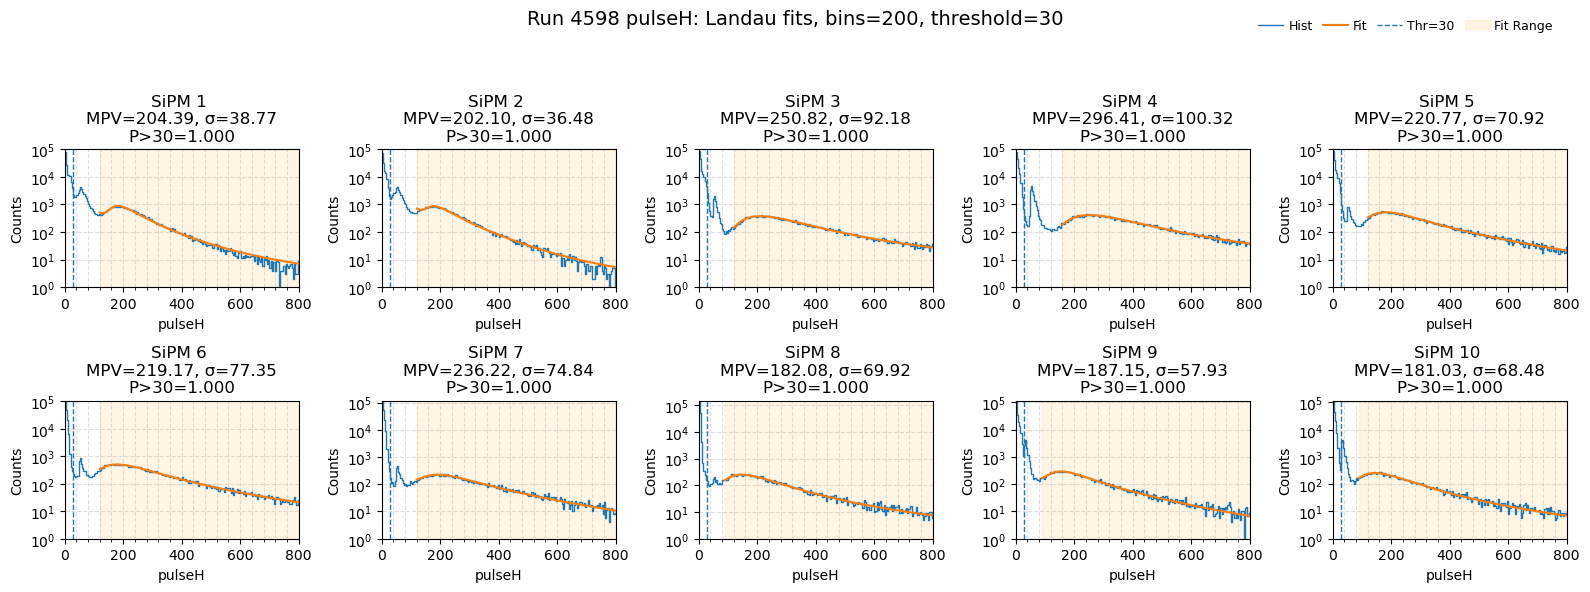

   channel panel              A         mpv       sigma         tau  \
0        1   top   84401.364627  204.385572   38.766923   95.915295   
1        2   top   62926.988306  202.095247   36.482175   97.351892   
2        3   top  121061.350848  250.817225   92.182302    0.269319   
3        4  wide  143271.223778  296.409161  100.323228  191.952697   
4        5   top   94522.967103  220.768334   70.924340  203.448935   
5        6   top  111551.756419  219.169093   77.350810  177.353005   
6        7   top   39015.447621  236.222025   74.840891  207.288938   
7        8  thin   54426.135327  182.077145   69.921387  134.251484   
8        9  thin   41498.327560  187.147302   57.929330  171.917174   
9       10  thin   50602.080989  181.031483   68.483681  138.122719   

             B          x0             C  threshold  p_detect  
0   756.135644   81.441202  1.084825e-37         30  1.000000  
1  1063.227455   79.384305  1.877244e-36         30  1.000000  
2     0.036272    0.095840

In [4]:
import ast

bins = 200
hist_range = (0, 800)
threshold = 30

file_path = "/raid1/genli/Data_D2O/M2_data/run4598_processed_H2O_v5.root"
output_path = "/raid1/genli/Data_D2O/output_from_jupyter/"
run_num = str(file_path.split("/")[-1].split("_")[0][3:])


def parse_array_cell(x):
    if isinstance(x, (list, np.ndarray)):
        return np.asarray(x, dtype=float)
    if pd.isna(x):
        return np.array([], dtype=float)
    s = str(x).strip()
    if s.startswith("[") and s.endswith("]"):
        s_inner = s[1:-1].strip()
        if not s_inner:
            return np.array([], dtype=float)
        try:
            return np.array(ast.literal_eval(s), dtype=float)
        except Exception:
            return np.fromstring(s_inner.replace(",", " "), sep=" ", dtype=float)
    return np.array([], dtype=float)


# load saved csv; deserialize array-like columns from strings back to numpy arrays
csv_path = f"{output_path}run{run_num}_data.csv"
df_muon = pd.read_csv(
    csv_path,
    converters={"pulseH": parse_array_cell, "area": parse_array_cell}
)

mask_muon = df_muon["triggerBits"] >= 32
df_muon = df_muon[mask_muon].reset_index(drop=True)

# Fit window (which bins to fit) per panel type
fit_ranges_by_panel = {
    "top":  (120, hist_range[1]),
    "wide": (160, hist_range[1]),
    "thin": (90, hist_range[1]),
}

# MPV allowed bounds per panel type
mpv_bounds_by_panel = {
    "top":  (120, 300),
    "wide": (160, 400),
    "thin": (90, 300),
}

df_results = fit_all_channels_and_prob(
    df_muon=df_muon,
    column="pulseH",
    bins=bins,
    hist_range=hist_range,
    fit_ranges_by_panel=fit_ranges_by_panel,
    mpv_bounds_by_panel=mpv_bounds_by_panel,
    threshold=threshold,
    make_plots=True
)

print(df_results)

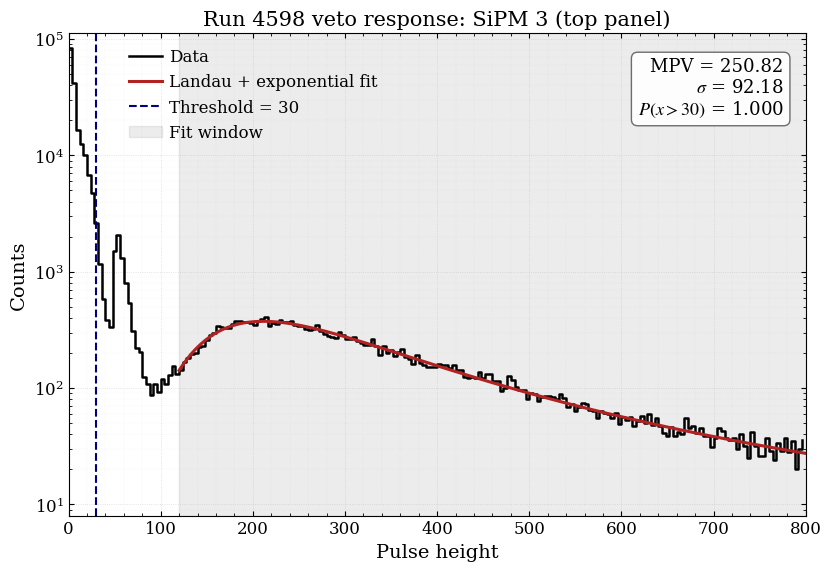

In [17]:
selected_channel = 3  # Choose SiPM channel from 1 to 10

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

if selected_channel not in PANEL_GROUP:
    raise ValueError("selected_channel must be between 1 and 10.")

channel_row = df_results.loc[df_results["channel"] == selected_channel]
if channel_row.empty:
    raise ValueError(f"No fit result found for SiPM {selected_channel}.")

channel_row = channel_row.iloc[0]
if pd.notna(channel_row.get("fit_error", np.nan)):
    raise RuntimeError(f"Fit failed for SiPM {selected_channel}: {channel_row['fit_error']}")

panel_type = PANEL_GROUP[selected_channel]
fit_range = fit_ranges_by_panel[panel_type]
channel_index = selected_channel + 11
channel_data = extract_channel_data(df_muon, "pulseH", channel_index)

counts, edges = np.histogram(channel_data, bins=bins, range=hist_range)
fit_x = np.linspace(fit_range[0], fit_range[1], 800)
fit_y = landau_plus_exp(
    fit_x,
    channel_row["A"],
    channel_row["mpv"],
    channel_row["sigma"],
    channel_row["tau"],
    channel_row["B"],
    channel_row["x0"],
    channel_row["C"],
)

fig, ax = plt.subplots(figsize=(8.2, 5.6), constrained_layout=True)
ax.step(edges[:-1], counts, where="post", linewidth=1.8, color="black", label="Data")
ax.plot(fit_x, fit_y, color="firebrick", linewidth=2.2, label="Landau + exponential fit")
ax.axvline(threshold, color="navy", linestyle="--", linewidth=1.5, label=fr"Threshold = {threshold}")
ax.axvspan(fit_range[0], fit_range[1], color="grey", alpha=0.15, label="Fit window")

ax.set_xlim(hist_range)
ax.set_yscale("log")
ax.set_ylim(8, max(20, counts.max() * 1.35))
ax.set_xlabel("Pulse height")
ax.set_ylabel("Counts")
ax.set_title(fr"Run {run_num} veto response: SiPM {selected_channel} ({panel_type} panel)")
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major", linestyle=":", linewidth=0.6, alpha=0.45)
ax.grid(which="minor", linestyle=":", linewidth=0.3, alpha=0.25)

annotation_text = "\n".join([
    fr"MPV = {channel_row['mpv']:.2f}",
    fr"$\sigma$ = {channel_row['sigma']:.2f}",
    fr"$P(x > {threshold})$ = {channel_row['p_detect']:.3f}",
])
ax.text(
    0.97,
    0.95,
    annotation_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "0.4", "alpha": 0.95},
)

ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.25, 1), ncol=1, columnspacing=0.8, handletextpad=0.4)
plt.show()